In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-deep")
plt.rcParams.update(
    {
        "text.usetex": True,  # Use LaTeX for text rendering
        "font.family": "serif",  # Use serif font
        "font.serif": ["Computer Modern Roman"],  # Use default LaTeX font
    }
)

In [2]:
df_lstm = pd.read_csv("../Results/lstm_hyper_opt.csv")
df_rnn = pd.read_csv("../Results/rnn_hyper_opt.csv")
df_vqc = pd.read_csv("../Results/vqc_hyper_opt.csv")
df_mlp = pd.read_csv("../Results/mlp_hyper_opt.csv")
df_qrnn = pd.read_csv("../Results/qrnn_paper_hyper_opt.csv")
df_qlstm_paper = pd.read_csv("../Results/qlstm_paper_hyper_opt.csv")
df_qlstm_le = pd.read_csv("../Results/qlstm_linear_enhanced_paper_hyper_opt.csv")

In [3]:
df_vqc_reuploading_expencnorm = df_vqc[df_vqc["Ansatz"].str.startswith("ruexp_")]
df_vqc_dressed = df_vqc[df_vqc["Ansatz"].str.startswith("paper_rivera-ruiz_with_inputlayer_")]
df_qrnn_reset = df_qrnn[df_qrnn["Ansatz"] == "paper_reset"]
df_qrnn_no_reset = df_qrnn[df_qrnn["Ansatz"] == "paper_no_reset"]

In [4]:
def find_best(df):
    df_intern = df.copy()
    best_rows = df_intern.loc[
        df_intern.groupby(["Prediction Step", "Data", "Sequence Length"], observed=True)[
            "MSE Validation Median"
        ].idxmin()
    ]
    return best_rows


best_lstm = find_best(df_lstm)
best_vqc_reuploading_expencnorm = find_best(df_vqc_reuploading_expencnorm)
best_vqc_dressed = find_best(df_vqc_dressed)
best_mlp = find_best(df_mlp)
best_qrnn_reset = find_best(df_qrnn_reset)
best_qrnn_no_reset = find_best(df_qrnn_no_reset)
best_qlstm_paper = find_best(df_qlstm_paper)
best_rnn = find_best(df_rnn)
best_qlstm_le = find_best(df_qlstm_le)

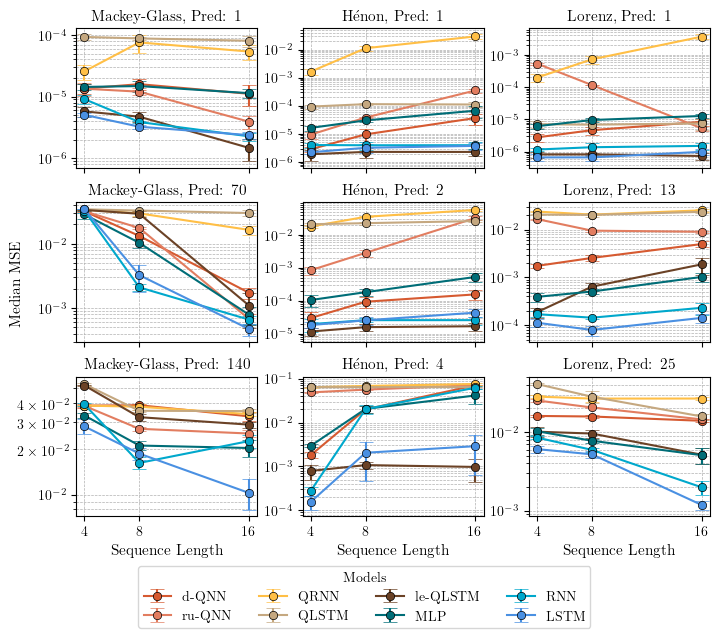

In [10]:
# Define sequence lengths and prediction steps for the axes and labels
sequence_lengths = [4, 8, 16]
prediction_steps_mackey = [1, 70, 140]
prediction_steps_henon = [1, 2, 4]
prediction_steps_lorenz = [1, 13, 25]

# Models and their colors (using the same dict from the notebook)
models = {
    "d-QNN": (best_vqc_dressed, "#D65A31"),
    "ru-QNN": (best_vqc_reuploading_expencnorm, "#E27D60"),
    "QRNN": (best_qrnn_no_reset, "#FFBF46"),
    "QLSTM": (best_qlstm_paper, "#C5A880"),
    "le-QLSTM": (best_qlstm_le, "#6B4226"),
    "MLP": (best_mlp, "#006D77"),
    "RNN": (best_rnn, "#00A8CC"),
    "LSTM": (best_lstm, "#4A90E2"),
}

# Data subsets and their titles (using the same dict from the notebook)
data = {
    "mackey_1000": (prediction_steps_mackey, "Mackey-Glass"),
    "henon_1000": (prediction_steps_henon, "Hénon"),
    "lorenz_1000": (prediction_steps_lorenz, "Lorenz"),
}

# Create the 3x3 subplot grid
fig, axs = plt.subplots(
    len(prediction_steps_mackey),
    len(data),
    figsize=(len(data) * 2.4, len(prediction_steps_mackey) * 2.1), # Increased size for better line plot readability
    sharey=False, # Share Y-axis across rows for comparison
    sharex=True,
)

# X-axis labels
x_labels = [str(sl) for sl in sequence_lengths]
x_positions = sequence_lengths # Use the actual sequence lengths for X-positions

# Loop through each row (Prediction Step) and column (Data Type)
for j, (data_label, (prediction_steps, data_title)) in enumerate(data.items()):
    for k, prediction_step in enumerate(prediction_steps):
        ax = axs[k, j]

        # Loop through each model to plot its performance across sequence lengths
        for i, (model_name, (df_best, color)) in enumerate(models.items()):

            # 1. Filter the best results for the current data and prediction step
            df_filtered = df_best[
                (df_best["Data"] == data_label) & (df_best["Prediction Step"] == prediction_step)
            ]

            # 2. Ensure data is ordered by Sequence Length for correct line plotting
            df_filtered = df_filtered.sort_values("Sequence Length")

            # 3. Plot the line with error bars
            if not df_filtered.empty:
                ax.errorbar(
                    df_filtered["Sequence Length"],
                    df_filtered["MSE Testing Median"],
                    yerr=df_filtered["MSE Testing Mad"],
                    label=model_name,
                    color=color,
                    marker='o', # Use a marker for data points
                    linestyle='-', # Plot as a line
                    capsize=5,
                    markeredgecolor="black",
                    markeredgewidth=0.5,
                    linewidth=1.5
                )

        # Set plot cosmetics
        ax.set_yscale("log")
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)
        ax.set_title(f"{data_title}, Pred: {prediction_step}", fontsize=11)
        ax.grid(True, which="both", linestyle='--', linewidth=0.5)
        ax.tick_params(axis="x", rotation=0)

        # Label axes only on the edges of the grid
        if k == len(prediction_steps) - 1: # Last row
            ax.set_xlabel("Sequence Length", fontsize=11)

# Create a single legend using the model handles
# We only need handles from the last plotted axis (k=2, j=2 in the loop structure)
handles, labels = axs[0, 0].get_legend_handles_labels()
# Remove duplicates if any were created (though errorbar should prevent this if plotted correctly)
by_label = dict(zip(labels, handles))
unique_handles = by_label.values()
unique_labels = by_label.keys()


fig.legend(
    unique_handles,
    unique_labels,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.0016),
    fontsize=10,
    title="Models",
)

fig.text(0.008, 0.56, "Median MSE", va="center", rotation="vertical", fontsize=11)
# Adjust layout to accommodate titles and legend
plt.tight_layout(rect=[0, 0.1, 1, 1]) # Make room for the legend below

# Final adjustment to ensure spacing is good
fig.subplots_adjust(left=0.1, right=0.98, top=0.965, bottom=0.19, wspace=0.25, hspace=0.25)

plt.savefig(f"all_models_mse_over_seq_len_lines.pdf")
plt.show()